In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('../data/processed/processed_data.csv')
print("shape:", df.shape)
df.head()

shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Data overview + data dictionary

In [7]:
print("Shape:", df.shape) 
print("\nColumns:") 
print(df.columns.tolist())

print("\nData Types:") 
display(df.dtypes.to_frame("dtype"))

print("\nBasic Statistics:") 
display(df.describe().T)

Shape: (10000, 14)

Columns:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Data Types:


,dtype
UDI,int64
Product ID,str
Type,str
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
Machine failure,int64
TWF,int64



Basic Statistics:


,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


## Target Distribution

In [8]:
target_counts = df["Machine failure"].value_counts().sort_index()
display(target_counts.to_frame("count"))
print("Failure rate:", round(df["Machine failure"].mean() * 100, 2), "%")

,count
Machine failure,
0,9661
1,339


Failure rate: 3.39 %


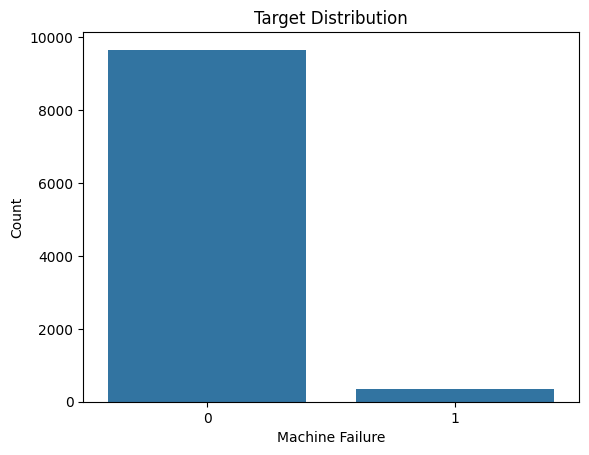

In [9]:
sns.countplot(x="Machine failure", data=df)
plt.title("Target Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Count")
plt.show()

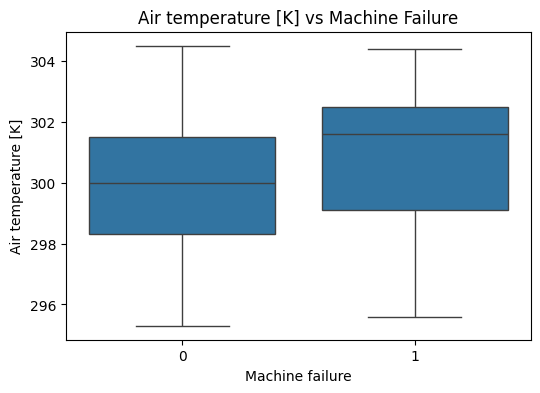

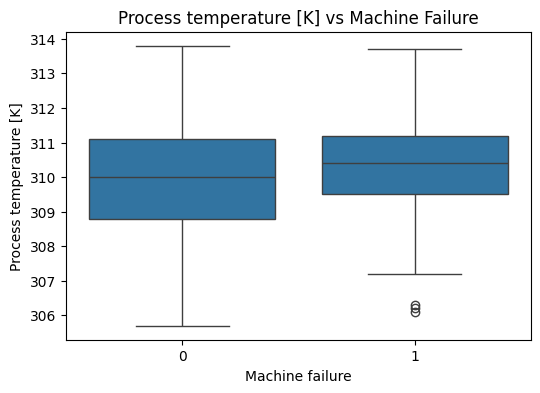

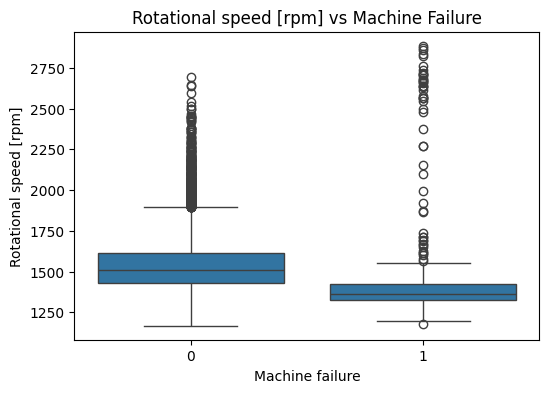

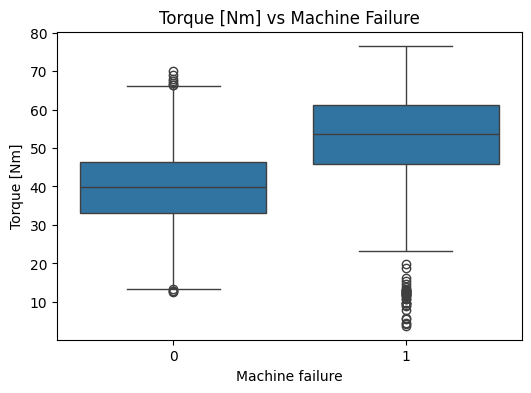

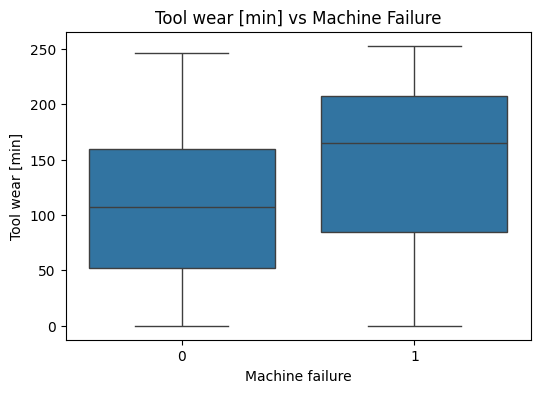

In [10]:
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for col in numeric_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="Machine failure", y=col)
    plt.title(f"{col} vs Machine Failure")
    plt.show()

## Failure Modes

In [11]:
failure_modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]

failure_mode_counts = df[failure_modes].sum().sort_values(ascending=False)

display(failure_mode_counts.to_frame("count"))

,count
HDF,115
OSF,98
PWF,95
TWF,46
RNF,19


## correlations

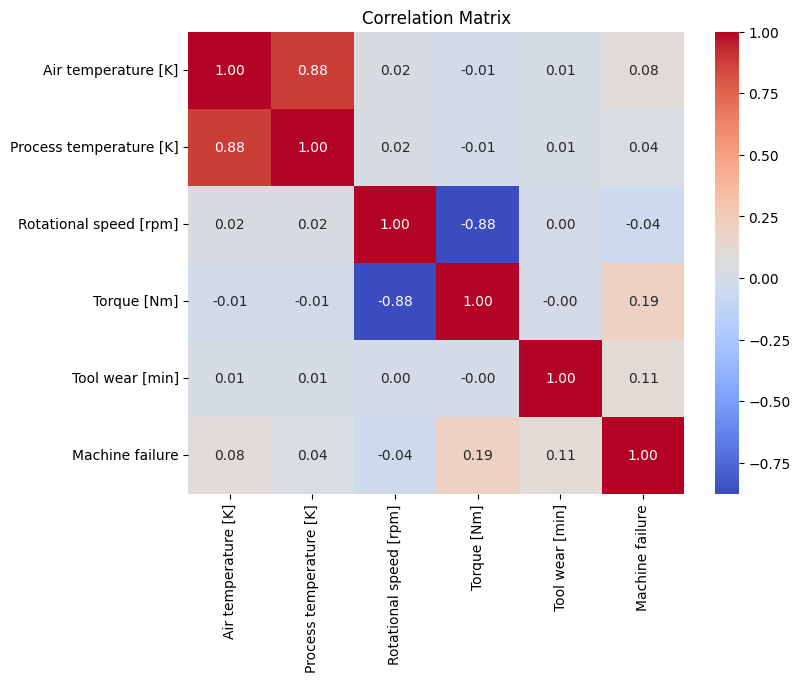

In [13]:
corr_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Machine failure"
]
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

-The strongest positive relationship between the features is between Air Temperature and Process Temperature with a correlation of 0.88.

-The strongest negative relationship is between Rotational Speed and Torque with a correlation of -0.88.

-Regarding Machine Failure, Torque has the strongest correlation with the target (0.19), followed by Tool Wear (0.11).

## Final EDA Insights
* The dataset contains 10,000 records and 14 variables, with no missing values and no exact duplicate rows.
* Machine Failure is highly imbalanced, with 339 failure cases (3.39%) compared with 9,661 non-failure cases. This makes class imbalance an important consideration for downstream model development.
* Among the observed failure modes, HDF had the highest number of cases (115), followed by OSF (98), PWF (95), TWF (46), and RNF (19).
* In the numerical feature analysis, Rotational Speed showed the most noticeable outliers, while Process Temperature showed some slight outliers. Air Temperature did not show obvious outliers.
* The strongest feature relationships were between Air Temperature and Process Temperature (0.88) and between Rotational Speed and Torque (-0.88).
* For the target variable, Torque showed the strongest correlation with Machine Failure (0.19), followed by Tool Wear (0.11).

Overall, the EDA indicates that machine failure prediction is an imbalanced classification problem with meaningful relationships among operating variables. These findings guided the subsequent feature-engineering stage and the selection of candidate features for predictive modeling.

##  2: Feature Engineering


In [15]:
#Temperature difference between process and air temperature
df["Temperature Difference [K]"] = (
    df["Process temperature [K]"] - df["Air temperature [K]"]
)

print("New shape:", df.shape)
display( df[ [ "Air temperature [K]", "Process temperature [K]", "Temperature Difference [K]", "Machine failure" ] ].head() )
print("\nTemperature Difference statistics:")
display(df["Temperature Difference [K]"].describe())

New shape: (10000, 15)


,Air temperature [K],Process temperature [K],Temperature Difference [K],Machine failure
0,298.1,308.6,10.5,0
1,298.2,308.7,10.5,0
2,298.1,308.5,10.4,0
3,298.2,308.6,10.4,0
4,298.2,308.7,10.5,0



Temperature Difference statistics:


count    10000.000000
mean        10.000630
std          1.001094
min          7.600000
25%          9.300000
50%          9.800000
75%         11.000000
max         12.100000
Name: Temperature Difference [K], dtype: float64


Since the project requirements do not specify a fixed set of engineered features, candidate features are created based on patterns observed during EDA.

The first candidate feature is Temperature Difference [K], calculated as:
Process Temperature - Air Temperature

This feature was selected because Air Temperature and Process Temperature showed a strong positive correlation (0.88) during the correlation analysis. The difference provides an additional representation of the relationship between the two temperature measurements.

This feature is considered a candidate feature, not a final selected feature. The final feature set will be determined later based on feature relevance and model performance.

In [17]:
df["Torque-Speed Interaction"] = ( df["Torque [Nm]"] * df["Rotational speed [rpm]"] )

print("New shape:", df.shape)
display( df[ [ "Rotational speed [rpm]", "Torque [Nm]", "Torque-Speed Interaction", "Machine failure" ] ].head() )
print("\nTorque-Speed Interaction statistics:")
display(df["Torque-Speed Interaction"].describe())

New shape: (10000, 16)


,Rotational speed [rpm],Torque [Nm],Torque-Speed Interaction,Machine failure
0,1551,42.8,66382.8,0
1,1408,46.3,65190.4,0
2,1498,49.4,74001.2,0
3,1433,39.5,56603.5,0
4,1408,40.0,56320.0,0



Torque-Speed Interaction statistics:


count    10000.000000
mean     59967.147040
std      10193.093881
min      10966.800000
25%      53105.400000
50%      59883.900000
75%      66873.750000
max      99980.400000
Name: Torque-Speed Interaction, dtype: float64

In [18]:

df["Tool Wear-Torque Interaction"] = ( df["Tool wear [min]"] * df["Torque [Nm]"] )
print("New shape:", df.shape)
display(
     df[
          [ "Tool wear [min]",
            "Torque [Nm]",
            "Tool Wear-Torque Interaction",
            "Machine failure" ] ].head() )

print("\nTool Wear-Torque Interaction statistics:")
display(df["Tool Wear-Torque Interaction"].describe())

New shape: (10000, 17)


,Tool wear [min],Torque [Nm],Tool Wear-Torque Interaction,Machine failure
0,0,42.8,0.0,0
1,3,46.3,138.9,0
2,5,49.4,247.0,0
3,7,39.5,276.5,0
4,9,40.0,360.0,0



Tool Wear-Torque Interaction statistics:


count    10000.000000
mean      4314.664550
std       2826.567692
min          0.000000
25%       1963.650000
50%       4012.950000
75%       6279.000000
max      16497.000000
Name: Tool Wear-Torque Interaction, dtype: float64

A candidate interaction feature was created between Tool Wear and Torque to represent their combined operating condition.

This feature will be evaluated later during feature selection rather than being assumed to be part of the final feature set.

## Evaluate candidate Features

In [19]:
candidate_features = [ "Temperature Difference [K]", "Torque-Speed Interaction", "Tool Wear-Torque Interaction" ]

feature_target_corr = (
     df[candidate_features + ["Machine failure"]]
       .corr()["Machine failure"] 
       .drop("Machine failure")
       .sort_values(key=abs, ascending=False) )
print("Correlation of candidate features with Machine Failure:")
display(feature_target_corr.to_frame("correlation"))

print("\nCandidate features:")
for feature in candidate_features:
     print("-", feature)

Correlation of candidate features with Machine Failure:


,correlation
Tool Wear-Torque Interaction,0.190427
Torque-Speed Interaction,0.176039
Temperature Difference [K],-0.111676



Candidate features:
- Temperature Difference [K]
- Torque-Speed Interaction
- Tool Wear-Torque Interaction


Candidate Feature Screening
The engineered features were initially screened using their correlation with Machine Failure.

Tool Wear-Torque Interaction showed the strongest correlation (0.190), followed by Torque-Speed Interaction (0.176) and Temperature Difference (-0.112).

This provides an initial indication of feature relevance; final feature selection will not be based on correlation alone.

## feature set comparision

In [23]:
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import average_precision_score

original_features = [ "Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]" ]

engineered_features = [ "Temperature Difference [K]", "Torque-Speed Interaction", "Tool Wear-Torque Interaction" ]

feature_sets = { "Baseline": original_features, "Engineered": original_features + engineered_features }

X_train, X_test, y_train, y_test = train_test_split( df[original_features + engineered_features], df["Machine failure"], test_size=0.2, random_state=42, stratify=df["Machine failure"] )

results = []
for name, features in feature_sets.items():
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train[features])
    X_test_scaled = scaler.transform(X_test[features])

    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )
    model.fit(X_train_scaled, y_train)

    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    pr_auc = average_precision_score(y_test, y_prob)
    results.append([
        name,
        len(features),
        pr_auc
    ])
comparison = pd.DataFrame( results, columns=["Feature Set", "Number of Features", "PR-AUC"] )
display(comparison)

,Feature Set,Number of Features,PR-AUC
0,Baseline,5,0.403445
1,Engineered,8,0.445203


Feature Set Comparison:
The engineered feature set improved the initial Logistic Regression PR-AUC from 0.403 using the original features to 0.445 after adding the engineered features.

This indicates that the engineered features provide additional predictive information and are therefore retained as candidate features for further evaluation.

In [24]:
from sklearn.ensemble import RandomForestClassifier

all_features = original_features + engineered_features
X = df[all_features]
y = df["Machine failure"]

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

feature_importance = (
    pd.DataFrame({
        "Feature": all_features,
        "Importance": rf.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance)

,Feature,Importance
0,Rotational speed [rpm],0.228290
1,Torque [Nm],0.175176
2,Torque-Speed Interaction,0.169891
3,Tool wear [min],0.136313
4,Tool Wear-Torque Interaction,0.119621
5,Temperature Difference [K],0.096945
6,Air temperature [K],0.043997
7,Process temperature [K],0.029768


Feature Importance Screening

Random Forest feature importance was used as an initial screening method for the candidate feature set.

Rotational Speed had the highest importance (0.228), followed by Torque (0.175) and Torque-Speed Interaction (0.170).

The engineered features also showed meaningful importance, particularly Torque-Speed Interaction and Tool Wear-Torque Interaction.

These results support retaining the engineered features as candidates for the final feature set. Final selection will be confirmed using model performance rather than feature importance alone.

In [ ]:
#last verification on train/test split and feature importance

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

X = df[all_features]
y = df["Machine failure"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

train_feature_importance = (
    pd.DataFrame({
        "Feature": all_features,
        "Importance": rf.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(train_feature_importance)


,Feature,Importance
0,Rotational speed [rpm],0.210293
1,Torque-Speed Interaction,0.183962
2,Torque [Nm],0.171567
3,Tool wear [min],0.139430
4,Tool Wear-Torque Interaction,0.124147
5,Temperature Difference [K],0.091116
6,Air temperature [K],0.047069
7,Process temperature [K],0.032416


Leakage-Safe Feature Selection Verification

To ensure that feature selection follows a leakage-safe validation process, the Random Forest feature-importance analysis was repeated using the training set only.

The feature-importance ranking remained broadly consistent with the initial screening performed on the complete dataset. Rotational Speed, Torque-Speed Interaction, Torque, and Tool Wear remained among the most important features, while the engineered features continued to show meaningful importance.

This consistency supports the reliability of the candidate feature set while ensuring that the test set was not used during feature selection.

Based on the feature-set comparison and the leakage-safe verification, the 8 candidate features are retained as the final feature set for downstream model development.

In [26]:
final_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature Difference [K]",
    "Torque-Speed Interaction",
    "Tool Wear-Torque Interaction"
]

## Final Feature Engineering Summary
The feature engineering process was guided by the EDA findings and focused on creating additional features that represent meaningful relationships between the machine operating variables.

Three candidate features were created:
* Temperature Difference [K] = Process Temperature − Air Temperature
* Torque-Speed Interaction = Torque × Rotational Speed
* Tool Wear-Torque Interaction = Tool Wear × Torque

The candidate feature set was compared with the original feature set using a Logistic Regression baseline. Adding the engineered features improved the PR-AUC from 0.403 to 0.445, indicating additional predictive information.

A Random Forest feature-importance analysis was then performed using the training set only to verify the feature relevance without using the test set during feature selection. The engineered features maintained meaningful importance, supporting their retention.

* Final Feature Set
The final feature set contains the original five numerical operating variables plus the three engineered features:
* Air temperature [K]
* Process temperature [K]
* Rotational speed [rpm]
* Torque [Nm]
* Tool wear [min]
* Temperature Difference [K]
* Torque-Speed Interaction
* Tool Wear-Torque Interaction

This 8-feature set is the final feature set to be passed to the downstream machine-learning pipeline.

# ML Team Handoff

## Final Feature Set

The downstream machine-learning pipeline should use the following
 **8 final features**:
- **Air temperature [K]**
- **Process temperature [K]**
- **Rotational speed [rpm]**
- **Torque [Nm]**
- **Tool wear [min]**
- **Temperature Difference [K]**
- **Torque-Speed Interaction**
- **Tool Wear-Torque Interaction**

## Target

The prediction target is **Machine failure**:
- 0 = No machine failure
- 1 = Machine failure


## Feature Engineering Formulas

The engineered features were created using the following relationships:

```python 
df["Temperature Difference [K]"] = (
    df["Process temperature [K]"] - df["Air temperature [K]"]
)
df["Torque-Speed Interaction"] = (
    df["Torque [Nm]"] * df["Rotational speed [rpm]"]
)
df["Tool Wear-Torque Interaction"] = (
    df["Tool wear [min]"] * df["Torque [Nm]"]
)

## Important Notes for the Machine-Learning Pipeline
* The final feature set contains 8 input features.
* The target is Machine failure.
* The dataset has a strong class imbalance, with a failure rate of 3.39%.
* Validation and preprocessing should remain leakage-safe, with learned transformations fitted using the training data only.
* The downstream ML stage should evaluate models using PR-AUC, recall, precision, F1-score, and false-negative rate, as required by the project.
* The failure-mode columns (TWF, HDF, PWF, OSF, RNF) should not be used as predictors of Machine failure, because they represent failure-related information that can cause target leakage.